# 중첩 계층 모형 (Nested Hierarchy) — 야구 타율, DBDA §9.5

이 노트북은 Kruschke, *Doing Bayesian Data Analysis* (2판) **§9.5 Extending the Hierarchy:
Subjects Within Categories** 를 **Stan / cmdstanpy** 로 재현한다 (JAGS 미사용).
앞 노트북(therapeutic touch)이 *하나의 집단* 안의 개인을 다뤘다면, 여기서는 **범주(category) 안의 개인**
이라는 **2단계 중첩 계층(nested hierarchy)** 을 다룬다.

**핵심 질문.** 야구 선수의 *타율(batting average)* = 안타/타석. 선수마다 타석 수가 천차만별이고,
**수비 포지션(position)** 에 따라 타격 기대치가 다르다(특히 투수는 타격을 거의 기대받지 않는다).
"선수의 진짜 타격 능력"을 어떻게 추정할까? → 선수는 *포지션* 안에, 포지션은 *리그 전체* 안에 속한다는
계층 구조로 모형화한다.

**이 노트북에서 다루는 것**
1. 중첩 계층 모형의 구조 (selfcontained 설명)
2. 데이터 탐색 (948명, 9개 포지션)
3. **Stan 모델** — 다이어그램의 화살표와 1:1 대응
4. 샘플링과 포지션 수준 결과
5. ⭐ **중첩 축소(shrinkage)**: 같은 기록·다른 포지션 → 다른 추정; 데이터량과 축소의 관계
6. 베이즈 계층 모델링의 장점 (추정 확실성이 "기여한 단위 수"에 의존한다는 점 포함)

> **실행 안내.** 샘플링 셀은 `cmdstanpy`(Stan)를 우선 사용하고, CmdStan 이 없으면 *동일 모델*을 표적으로 하는
> NumPy 블록-Metropolis 대체 샘플러로 자동 전환된다(그림이 그대로 그려짐). 실제 분석은 CmdStan 환경에서 권장.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import arviz as az
from scipy.special import betaln, gammaln, expit, logit
az.style.use("arviz-darkgrid")
print("numpy", np.__version__, "| arviz", az.__version__)

numpy 2.2.6 | arviz 0.23.4


## 1. 중첩 계층 모형의 구조

앞 노트북의 "동전과 주조소" 비유를 한 단계 확장한다: 이제 **여러 종류(category)의 주조소**가 있고,
각 주조소가 여러 동전을 만든다. 야구로 번역하면 — *리그 전체* → *포지션* → *선수*.

$$
\begin{aligned}
z_s \mid \theta_s &\sim \text{Binomial}(N_s,\ \theta_s) && \text{선수 }s\text{의 안타 (가능도)}\\
\theta_s \mid \omega_{c[s]},\kappa_{c[s]} &\sim \text{Beta}\big(\omega_{c[s]}(\kappa_{c[s]}-2)+1,\ (1-\omega_{c[s]})(\kappa_{c[s]}-2)+1\big) && \text{포지션 }c[s]\text{ 안의 선수}\\
\omega_c \mid \omega_0,\kappa_0 &\sim \text{Beta}\big(\omega_0(\kappa_0-2)+1,\ (1-\omega_0)(\kappa_0-2)+1\big) && \text{전체 안의 포지션}\\
\kappa_c - 2 &\sim \text{Gamma}(0.01,0.01),\qquad \omega_0 \sim \text{Beta}(1,1),\qquad \kappa_0-2 \sim \text{Gamma}(0.01,0.01)
\end{aligned}
$$

- $\theta_s$ : 선수 $s$ 의 참 타격확률. $c[s]$ 는 그 선수의 포지션 인덱스(*nested indexing*).
- $\omega_c,\kappa_c$ : 포지션 $c$ 의 최빈 타격능력과 집중도.
- $\omega_0,\kappa_0$ : 리그 전체의 최빈 타격능력과 (포지션들이 흩어진 정도) 집중도.

> 단순화를 위해 포지션별 집중도 $\kappa_c$ 위에는 상위 분포를 두지 않았다(각 $\kappa_c$ 는 독립적인
> 약한 감마 사전을 가짐). 책의 모형과 동일하다.

직관: 각 선수 추정치는 (1) 자기 타석 기록과 (2) **자기 포지션의 분포**에 동시에 끌린다.
포지션 분포는 그 포지션 *모든 선수*가 함께 결정하고, 포지션들은 다시 전체 분포를 함께 결정한다.

## 2. 데이터: 2012 MLB 타격 (948명, 9개 포지션)

각 행은 한 선수: 이름(Player), 주 포지션(PriPos), 안타(Hits), 타석(AtBats). 투수는 타석이 매우 적고
(중앙값 ~4타석), 외야수·포수 등은 훨씬 많다.

In [2]:
df = pd.read_csv("BattingAverage.csv")
df["BatAvg"] = df["Hits"]/df["AtBats"]
cats = sorted(df["PriPos"].unique())
cidx = {c:i for i,c in enumerate(cats)}
z = df["Hits"].to_numpy(); N = df["AtBats"].to_numpy()
cc = df["PriPos"].map(cidx).to_numpy()        # 0-based category index per player
Ncat = len(cats); Nsubj = len(df)
print(f"선수 {Nsubj}명, 포지션 {Ncat}개, 전체 타율 {z.sum()/N.sum():.3f}")
df.groupby("PriPos").agg(players=("Player","size"),
                         median_AtBats=("AtBats","median"),
                         batavg=("Hits","sum")).assign(
                         batavg=lambda d: d["batavg"]/df.groupby("PriPos")["AtBats"].sum())

선수 948명, 포지션 9개, 전체 타율 0.255


,players,median_AtBats,batavg
PriPos,,,
1st Base,81,265.0,0.258851
2nd Base,72,228.5,0.255676
3rd Base,75,267.0,0.265036
Catcher,103,170.0,0.247404
Center Field,67,259.0,0.263513
Left Field,103,164.0,0.259077
Pitcher,324,4.0,0.129148
Right Field,60,340.5,0.263555
Shortstop,63,205.0,0.255186


/sessions/laughing-vibrant-wozniak/tmp/ipykernel_7/3118058102.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=True, labels=order, showfliers=False)
/sessions/laughing-vibrant-wozniak/tmp/ipykernel_7/3118058102.py:11: UserWarning: The figure layout has changed to tight
  ax.tick_params(axis="x", rotation=30); ax.legend(); plt.tight_layout(); plt.show()


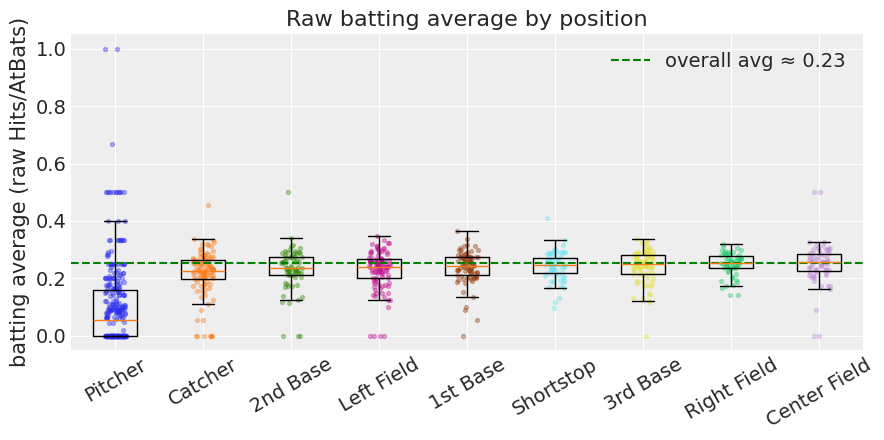

In [3]:
# 포지션별 타율 분포 (원자료) — 투수가 확연히 낮다
fig, ax = plt.subplots(figsize=(9,4.5))
order = df.groupby("PriPos")["BatAvg"].median().sort_values().index
data = [df.loc[df.PriPos==p,"BatAvg"].values for p in order]
ax.boxplot(data, vert=True, labels=order, showfliers=False)
for i,p in enumerate(order,1):
    xs = df.loc[df.PriPos==p,"BatAvg"].values
    ax.scatter(np.full_like(xs,i)+np.random.uniform(-0.12,0.12,len(xs)), xs, s=8, alpha=0.35)
ax.axhline(z.sum()/N.sum(), color="green", ls="--", label="overall avg ≈ 0.23")
ax.set_ylabel("batting average (raw Hits/AtBats)"); ax.set_title("Raw batting average by position")
ax.tick_params(axis="x", rotation=30); ax.legend(); plt.tight_layout(); plt.show()

## 3. Stan 모델 — 다이어그램의 화살표와 1:1 대응

| 수학 (math) | Stan |
|---|---|
| $z_s\sim\text{Binomial}(N_s,\theta_s)$ | `z ~ binomial(N, theta);` |
| $\theta_s\sim\text{Beta}(\omega_{c[s]}(\kappa_{c[s]}-2)+1,\dots)$ | `theta ~ beta(omega[c].*(kappa[c]-2)+1, ...);` |
| $\omega_c\sim\text{Beta}(\omega_0(\kappa_0-2)+1,\dots)$ | `omega ~ beta(omega0*(kappa0-2)+1, ...);` |
| $\kappa_c-2\sim\text{Gamma}(0.01,0.01)$ | `kappaMinusTwo ~ gamma(0.01,0.01);` |
| $\omega_0\sim\text{Beta}(1,1),\ \kappa_0-2\sim\text{Gamma}(0.01,0.01)$ | 해당 두 줄 |

`omega[c]` 처럼 **중첩 인덱싱**으로 각 선수에게 자기 포지션의 모수를 연결한다(`.*` 는 원소별 곱).

In [4]:
stan_code = r"""
data {
  int<lower=1> Nsubj;
  int<lower=1> Ncat;
  array[Nsubj] int<lower=0> z;                 // 안타
  array[Nsubj] int<lower=1> N;                 // 타석
  array[Nsubj] int<lower=1, upper=Ncat> c;     // 선수의 포지션 인덱스 (nested)
}
parameters {
  real<lower=0, upper=1> omega0;               // 전체 최빈 타격능력
  real<lower=0> kappa0MinusTwo;                // 전체 집중도 - 2
  vector<lower=0, upper=1>[Ncat] omega;        // 포지션별 최빈
  vector<lower=0>[Ncat] kappaMinusTwo;         // 포지션별 집중도 - 2
  vector<lower=0, upper=1>[Nsubj] theta;       // 선수별 타격확률
}
transformed parameters {
  real<lower=2> kappa0 = kappa0MinusTwo + 2;
  vector<lower=2>[Ncat] kappa = kappaMinusTwo + 2;
}
model {
  omega0 ~ beta(1, 1);
  kappa0MinusTwo ~ gamma(0.01, 0.01);
  omega ~ beta(omega0*(kappa0-2)+1, (1-omega0)*(kappa0-2)+1);     // 전체 안의 포지션
  kappaMinusTwo ~ gamma(0.01, 0.01);
  theta ~ beta(omega[c].*(kappa[c]-2)+1, (1-omega[c]).*(kappa[c]-2)+1);  // 포지션 안의 선수
  z ~ binomial(N, theta);                                        // 가능도
}
"""
with open("baseball_nested.stan","w") as f: f.write(stan_code)
print(stan_code)


data {
  int<lower=1> Nsubj;
  int<lower=1> Ncat;
  array[Nsubj] int<lower=0> z;                 // 안타
  array[Nsubj] int<lower=1> N;                 // 타석
  array[Nsubj] int<lower=1, upper=Ncat> c;     // 선수의 포지션 인덱스 (nested)
}
parameters {
  real<lower=0, upper=1> omega0;               // 전체 최빈 타격능력
  real<lower=0> kappa0MinusTwo;                // 전체 집중도 - 2
  vector<lower=0, upper=1>[Ncat] omega;        // 포지션별 최빈
  vector<lower=0>[Ncat] kappaMinusTwo;         // 포지션별 집중도 - 2
  vector<lower=0, upper=1>[Nsubj] theta;       // 선수별 타격확률
}
transformed parameters {
  real<lower=2> kappa0 = kappa0MinusTwo + 2;
  vector<lower=2>[Ncat] kappa = kappaMinusTwo + 2;
}
model {
  omega0 ~ beta(1, 1);
  kappa0MinusTwo ~ gamma(0.01, 0.01);
  omega ~ beta(omega0*(kappa0-2)+1, (1-omega0)*(kappa0-2)+1);     // 전체 안의 포지션
  kappaMinusTwo ~ gamma(0.01, 0.01);
  theta ~ beta(omega[c].*(kappa[c]-2)+1, (1-omega[c]).*(kappa[c]-2)+1);  // 포지션 안의 선수
  z ~ binomial(N, theta);                                  

## 4. 샘플링 (cmdstanpy)

모수는 $948$(선수) $+ 9\times2$(포지션) $+2$(전체) ≈ **968개**. CmdStan 이 없으면 동일 모델을 표적으로 하는
NumPy **블록 Metropolis-within-Gibbs** 로 자동 전환된다(조건부 독립성을 이용해 $\theta$·$\omega_c$·$\kappa_c$ 를
블록 단위로 갱신하므로 빠르다).

In [5]:
cpos = (cc+1).astype(int)  # Stan 은 1-based
stan_data = {"Nsubj":int(Nsubj),"Ncat":int(Ncat),
             "z":z.astype(int).tolist(),"N":N.astype(int).tolist(),"c":cpos.tolist()}
idata=None; backend=None
try:
    from cmdstanpy import CmdStanModel
    model=CmdStanModel(stan_file="baseball_nested.stan")
    fit=model.sample(data=stan_data, chains=4, iter_warmup=1000, iter_sampling=1000,
                     seed=11, adapt_delta=0.95, show_progress=False)
    idata=az.from_cmdstanpy(fit, coords={"position":cats,"player":df["Player"].tolist()},
                            dims={"omega":["position"],"kappa":["position"],"theta":["player"]})
    backend="Stan / cmdstanpy (NUTS)"
    print(fit.diagnose())
except Exception as e:
    print("[info] CmdStan 사용 불가 -> NumPy 블록 Metropolis 대체 샘플러로 전환")
    print("       reason:", str(e).splitlines()[0][:160])

if idata is None:
    def beta_lp(th,a,b): return (a-1)*np.log(th)+(b-1)*np.log1p(-th)-betaln(a,b)
    def gam_lp(x,sh,rt): return (sh-1)*np.log(x)-rt*x
    def ab(om,ka): return om*(ka-2)+1,(1-om)*(ka-2)+1
    def run_chain(seed,n_iter=8000,burn=3000,thin=3):
        rng=np.random.default_rng(seed); S=Nsubj; C=Ncat
        th=(z+1)/(N+2.0)
        om=np.array([(z[cc==k].sum()+1)/(N[cc==k].sum()+2) for k in range(C)])
        ka=np.full(C,20.0); om0=0.25; ka0=20.0
        st_th=np.full(S,0.35); st_om=np.full(C,0.05); st_ka=np.full(C,0.45); st_om0=0.12; st_ka0=0.5
        OM=[];TH=[];OM0=[];KA=[];KA0=[]
        for it in range(n_iter):
            a_c,b_c=ab(om,ka)
            thp=expit(logit(th)+rng.normal(0,st_th,S))
            cur=z*np.log(th)+(N-z)*np.log1p(-th)+beta_lp(th,a_c[cc],b_c[cc])+np.log(th)+np.log1p(-th)
            pro=z*np.log(thp)+(N-z)*np.log1p(-thp)+beta_lp(thp,a_c[cc],b_c[cc])+np.log(thp)+np.log1p(-thp)
            acc=np.log(rng.random(S))<pro-cur; th=np.where(acc,thp,th)
            A0,B0=ab(om0,ka0); a_c,b_c=ab(om,ka)
            cs=lambda v: np.bincount(cc,weights=v,minlength=C)
            omp=expit(logit(om)+rng.normal(0,st_om,C)); ap,bp=ab(omp,ka)
            cur=cs(beta_lp(th,a_c[cc],b_c[cc]))+beta_lp(om,A0,B0)+np.log(om)+np.log1p(-om)
            pro=cs(beta_lp(th,ap[cc],bp[cc]))+beta_lp(omp,A0,B0)+np.log(omp)+np.log1p(-omp)
            acc=np.log(rng.random(C))<pro-cur; om=np.where(acc,omp,om)
            a_c,b_c=ab(om,ka)
            kap=np.exp(np.log(ka-2)+rng.normal(0,st_ka,C))+2; ap,bp=ab(om,kap)
            cur=cs(beta_lp(th,a_c[cc],b_c[cc]))+gam_lp(ka-2,0.01,0.01)+np.log(ka-2)
            pro=cs(beta_lp(th,ap[cc],bp[cc]))+gam_lp(kap-2,0.01,0.01)+np.log(kap-2)
            acc=np.log(rng.random(C))<pro-cur; ka=np.where(acc,kap,ka)
            A0,B0=ab(om0,ka0); om0p=expit(logit(om0)+rng.normal()*st_om0); A0p,B0p=ab(om0p,ka0)
            if np.log(rng.random())<(np.sum(beta_lp(om,A0p,B0p))+np.log(om0p)+np.log1p(-om0p))-(np.sum(beta_lp(om,A0,B0))+np.log(om0)+np.log1p(-om0)): om0=om0p
            A0,B0=ab(om0,ka0); ka0p=np.exp(np.log(ka0-2)+rng.normal()*st_ka0)+2; A0p,B0p=ab(om0,ka0p)
            if np.log(rng.random())<(np.sum(beta_lp(om,A0p,B0p))+gam_lp(ka0p-2,.01,.01)+np.log(ka0p-2))-(np.sum(beta_lp(om,A0,B0))+gam_lp(ka0-2,.01,.01)+np.log(ka0-2)): ka0=ka0p
            if it>=burn and (it-burn)%thin==0:
                OM.append(om.copy());TH.append(th.copy());OM0.append(om0);KA.append(ka.copy());KA0.append(ka0)
        return map(np.array,(OM,KA,TH,OM0,KA0))
    OMc=[];KAc=[];THc=[];OM0c=[];KA0c=[]
    for ch in range(3):
        OM,KA,TH,OM0,KA0=run_chain(11+ch)
        OMc.append(OM);KAc.append(KA);THc.append(TH);OM0c.append(OM0);KA0c.append(KA0)
    idata=az.from_dict(posterior={
        "omega":np.array(OMc),"kappa":np.array(KAc),"theta":np.array(THc),
        "omega0":np.array(OM0c),"kappa0":np.array(KA0c)},
        coords={"position":cats,"player":df["Player"].tolist()},
        dims={"omega":["position"],"kappa":["position"],"theta":["player"]})
    backend="NumPy fallback (block Metropolis, same model)"
print("\nBackend used:", backend)

/sessions/laughing-vibrant-wozniak/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
04:47:49 - cmdstanpy - INFO - No CmdStan installation found.


04:47:49 - cmdstanpy - INFO - Cannot determine whether version is before 2.27.


04:47:49 - cmdstanpy - INFO - No CmdStan installation found.


04:47:49 - cmdstanpy - INFO - Cannot determine whether version is before 2.36.


04:47:49 - cmdstanpy - INFO - compiling stan file /sessions/laughing-vibrant-wozniak/mnt/outputs/baseball_nested.stan to exe file /sessions/laughing-vibrant-wozniak/mnt/outputs/baseball_nested


[info] CmdStan 사용 불가 -> NumPy 블록 Metropolis 대체 샘플러로 전환
       reason: No CmdStan directory, path /tmp/no_cmdstan_here does not exist.



Backend used: NumPy fallback (block Metropolis, same model)


In [6]:
# 포지션 수준 + 전체 요약
az.summary(idata, var_names=["omega0","omega"], round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
omega0,0.227,0.022,0.185,0.268,0.001,0.001,1292.866,1294.359,1.001
omega[1st Base],0.251,0.005,0.243,0.261,0.000,0.000,777.841,1565.850,1.006
omega[2nd Base],0.248,0.005,0.238,0.258,0.000,0.000,829.648,1522.426,1.001
omega[3rd Base],0.255,0.005,0.245,0.265,0.000,0.000,725.554,1754.789,1.001
omega[Catcher],0.237,0.005,0.228,0.247,0.000,0.000,644.087,1284.106,1.002
omega[Center Field],0.256,0.006,0.246,0.267,0.000,0.000,950.757,1744.154,1.001
omega[Left Field],0.249,0.005,0.240,0.258,0.000,0.000,636.635,990.974,1.008
omega[Pitcher],0.122,0.006,0.111,0.133,0.001,0.000,127.576,157.838,1.019
omega[Right Field],0.259,0.005,0.251,0.268,0.000,0.000,814.947,1227.396,1.009
omega[Shortstop],0.247,0.006,0.237,0.258,0.000,0.000,719.594,1485.936,1.003


## 5. 결과: 포지션 수준 추정과 차이

각 포지션의 최빈 타격능력 $\omega_c$ 와 전체 $\omega_0$. 투수가 확연히 낮고, 포수·내야는 비슷하게 높다.

/sessions/laughing-vibrant-wozniak/tmp/ipykernel_7/1725640916.py:6: UserWarning: The figure layout has changed to tight
  ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


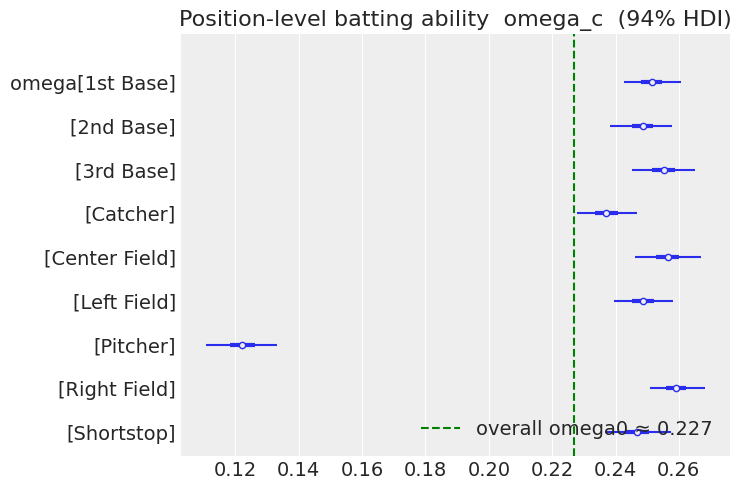

In [7]:
fig, ax = plt.subplots(figsize=(7.5,5))
az.plot_forest(idata, var_names=["omega"], combined=True, ax=ax)
ax.axvline(float(idata.posterior["omega0"].mean()), color="green", ls="--",
           label=f"overall omega0 ≈ {float(idata.posterior['omega0'].mean()):.3f}")
ax.set_title("Position-level batting ability  omega_c  (94% HDI)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

/sessions/laughing-vibrant-wozniak/tmp/ipykernel_7/2314464945.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


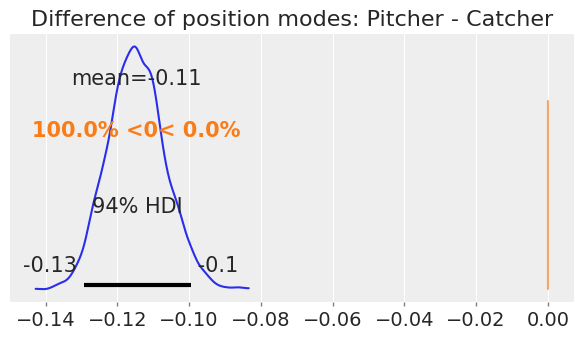

P(omega_Pitcher < omega_Catcher) = 1.000


In [8]:
# Pitcher 와 Catcher 의 차이 (책: mode ≈ -0.116, 100% < 0)
pi=cats.index("Pitcher"); ca=cats.index("Catcher")
diff = (idata.posterior["omega"].sel(position="Pitcher")
        - idata.posterior["omega"].sel(position="Catcher")).values.ravel()
fig,ax=plt.subplots(figsize=(6,3.5))
az.plot_posterior({"Pitcher - Catcher":diff}, ref_val=0.0, ax=ax)
ax.set_title("Difference of position modes: Pitcher - Catcher")
plt.tight_layout(); plt.show()
print(f"P(omega_Pitcher < omega_Catcher) = {np.mean(diff<0):.3f}")

## 6. ⭐ 중첩 축소 (Shrinkage)

### (a) 같은 기록, 다른 포지션 → 다른 추정
**Kyle Blanks**(1루수, 1/5)와 **Bruce Chen**(투수, 1/5)은 타격 기록이 *완전히 동일*하다.
하지만 추정 능력은 다르다 — 타석이 적어 추정이 **포지션 정보에 지배**되기 때문이다.
(만약 포지션을 무시하고 948명을 한 집단에 넣었다면, 둘의 추정치는 동일했을 것이다.)

/sessions/laughing-vibrant-wozniak/tmp/ipykernel_7/641505872.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


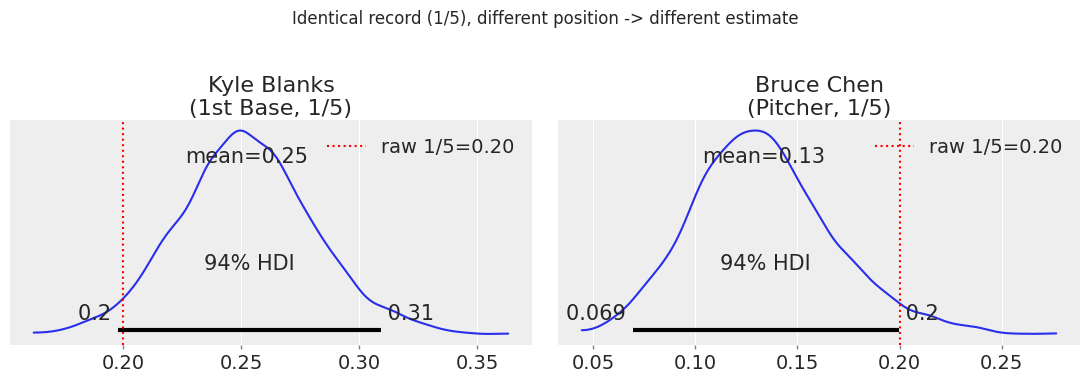

In [9]:
def theta_of(name):
    i = df.index[df["Player"]==name][0]
    return idata.posterior["theta"].isel(player=i).values.ravel(), df.loc[i,"Hits"], df.loc[i,"AtBats"], df.loc[i,"PriPos"]

fig, axes = plt.subplots(1,2, figsize=(11,3.6))
for ax,name in zip(axes, ["Kyle Blanks","Bruce Chen"]):
    s,h,n,pos = theta_of(name)
    az.plot_posterior(s, ax=ax); ax.axvline(h/n, color="red", ls=":", label=f"raw {h}/{n}={h/n:.2f}")
    ax.set_title(f"{name}\n({pos}, {h}/{n})"); ax.legend()
plt.suptitle("Identical record (1/5), different position -> different estimate", y=1.05)
plt.tight_layout(); plt.show()

### (b) 데이터가 많으면 축소가 작고 추정이 더 확실
**ShinSoo Choo**(우익수, 169/598)와 **Ichiro Suzuki**(우익수, 178/629)는 타석이 매우 많다.
사후분포의 폭(HDI)이 좁고, 그래도 원자료(+표시)에서 포지션 최빈값(~0.247) 쪽으로 *약간* 축소된다.

/sessions/laughing-vibrant-wozniak/tmp/ipykernel_7/3446820134.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


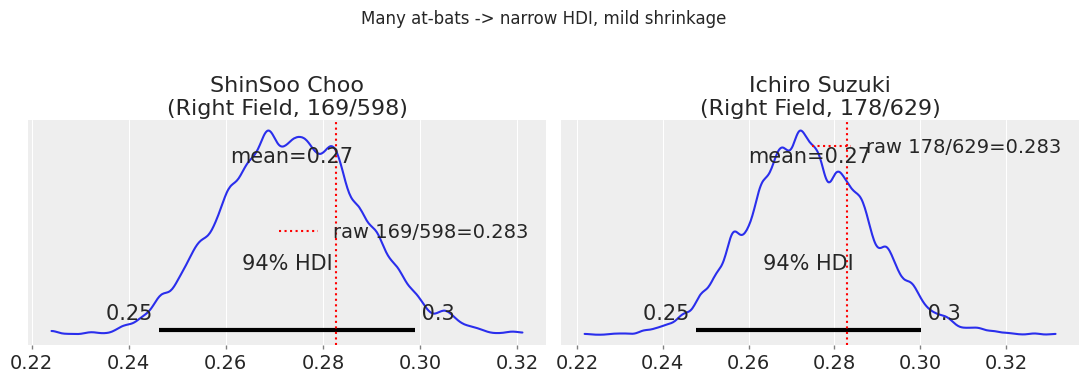

In [10]:
fig, axes = plt.subplots(1,2, figsize=(11,3.6))
for ax,name in zip(axes, ["ShinSoo Choo","Ichiro Suzuki"]):
    s,h,n,pos = theta_of(name)
    az.plot_posterior(s, ax=ax); ax.axvline(h/n, color="red", ls=":", label=f"raw {h}/{n}={h/n:.3f}")
    ax.set_title(f"{name}\n({pos}, {h}/{n})"); ax.legend()
plt.suptitle("Many at-bats -> narrow HDI, mild shrinkage", y=1.05)
plt.tight_layout(); plt.show()

/sessions/laughing-vibrant-wozniak/tmp/ipykernel_7/1570023187.py:13: UserWarning: The figure layout has changed to tight
  ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()


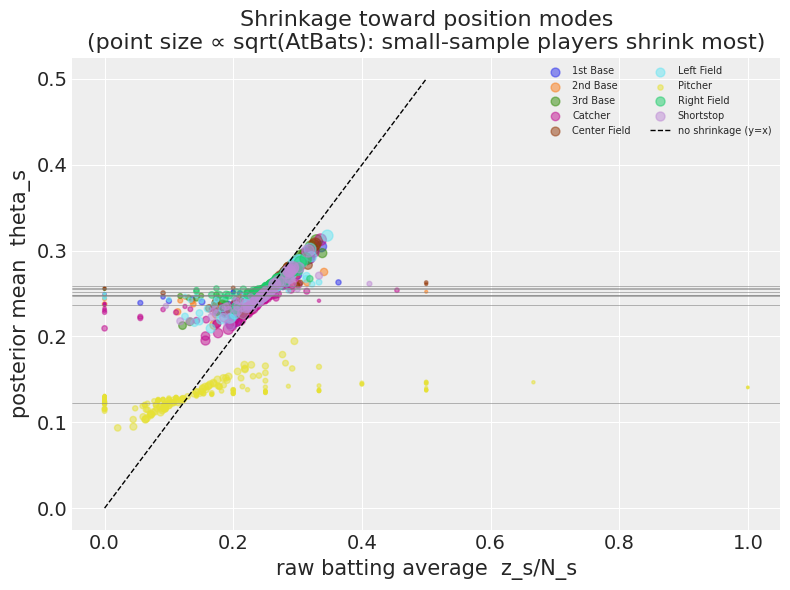

In [11]:
# 전체 축소 그림: 원자료 타율 vs 사후평균 theta, 포지션별 색, 점 크기 = 타석수
post_theta = idata.posterior["theta"].mean(dim=("chain","draw")).values
raw = z/N
om_c = idata.posterior["omega"].mean(dim=("chain","draw")).values
fig, ax = plt.subplots(figsize=(8,6))
for k,p in enumerate(cats):
    m = cc==k
    ax.scatter(raw[m], post_theta[m], s=np.sqrt(N[m])*3, alpha=0.5, label=p)
    ax.axhline(om_c[k], color="grey", lw=0.4)
ax.plot([0,0.5],[0,0.5],"k--",lw=1,label="no shrinkage (y=x)")
ax.set_xlabel("raw batting average  z_s/N_s"); ax.set_ylabel("posterior mean  theta_s")
ax.set_title("Shrinkage toward position modes\n(point size ∝ sqrt(AtBats): small-sample players shrink most)")
ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

위 그림에서 점들이 대각선 $y=x$(축소 없음)보다 **수평선(포지션 최빈값)** 쪽으로 눌려 있다.
**타석이 적은 작은 점일수록** 자기 포지션 최빈값으로 더 강하게 당겨지고(=원자료에서 멀어짐),
타석이 많은 큰 점은 대각선에 가깝다(=자기 데이터를 더 신뢰). 이것이 중첩 계층 축소의 핵심이다.

## 7. 베이즈 (중첩) 계층 모델링의 장점

1. **구조가 곧 모형.** "선수 ⊂ 포지션 ⊂ 리그"라는 도메인 지식을 다이어그램으로 그리면 그대로 Stan 모형이 된다.
   (질병 치료 ⊂ 치료유형, 학생 ⊂ 학교구 등 어디에나 적용된다.)
2. **데이터에 비례한 축소.** 타석이 적은 선수는 포지션 정보에 더 의존하고, 많은 선수는 자기 기록을 더 신뢰한다.
   잡음(우연)에 강건한 추정을 자동으로 준다.
3. **추정 확실성이 "기여 단위 수"에 의존.** 전체 $\omega_0$ 에는 9개 포지션만 기여하므로 HDI 가 넓고
   (폭 ~0.09), 각 포지션 $\omega_c$ 에는 수십~수백 선수가 기여하므로 HDI 가 좁다(폭 ~0.02).
   이는 계층 추정의 자연스러운 성질이다.
4. **모든 비교가 하나의 사후분포에서.** "투수 vs 포수", "선수 A vs B" 등 어떤 비교든 결합 사후분포에서
   일관되게 확률로 답한다 — 다중비교 보정 같은 임시방편이 필요 없다.
5. **불확실성의 완전한 표현.** 점추정이 아니라 분포 전체를 얻으므로, 차이의 95% HDI 가 0(또는 ROPE)을
   포함하는지로 실질적 결론을 내릴 수 있다.

> 모형은 데이터에 대한 *의미 있는 기술*이지 유일한 정답이 아니다. 포지션으로 범주화할지 말지는
> "무엇이 데이터의 의미 있는 측면인가"에 대한 분석자의 판단이며, 그 선택이 추정치의 해석을 규정한다.

## 8. 정리

- **중첩 계층**은 "범주 안의 개인"을 자연스럽게 모형화하고, 축소를 *범주 수준*에서 작동시킨다.
- 같은 기록이라도 포지션(범주)이 다르면 추정이 달라지고, 데이터가 적을수록 범주 정보에 더 의존한다.
- 추정의 확실성은 그 수준에 기여하는 단위 수에 비례하며, 베이즈 사후분포는 이 모든 것을 일관된 확률로 표현한다.

### 참고문헌
- Kruschke, J. K. (2015). *Doing Bayesian Data Analysis*, 2nd ed., §9.5. Academic Press.
- 데이터: 2012 MLB 정규시즌 타격 기록 (`BattingAverage.csv`).